
# 🚖 Complete Ride Dataset Preprocessing & Feature Engineering Project

## Full Practical Exam Notebook
This notebook includes:
- Data Loading
- Data Cleaning
- Missing Value Handling
- Outlier Handling
- Feature Construction
- Encoding
- Feature Scaling
- Visualizations
- Final Dataset Export


In [117]:

# ====================================
# Import Libraries
# ====================================

import pandas as pd
import numpy as np
import sqlite3
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler
)

from scipy.stats import zscore
from scipy.stats.mstats import winsorize


## 1. Data Loading

In [118]:

# Load CSV
riders_df = pd.read_csv('riders.csv')

# Load JSON
trips_df = pd.read_json('trips.json')

# Load SQL
conn = sqlite3.connect('city_zones.db')

with open('city_zones.sql', 'r') as file:
    sql_script = file.read()

conn.executescript(sql_script)

zones_df = pd.read_sql_query("SELECT * FROM city_zones", conn)

print(riders_df.head())
print(trips_df.head())
print(zones_df.head())


  rider_id         name  age  gender       city signup_date  total_rides  \
0    R0001    Aarav Das   23    Male       Pune  2020-06-29           56   
1    R0002  Ishaan Nair   39  Female     Mumbai  2019-11-23           70   
2    R0003  Kavya Reddy   34    Male       Pune  2023-05-04           45   
3    R0004   Aarav Nair   19   Other    Kolkata  2019-07-28          464   
4    R0005   Diya Reddy   27    Male  Ahmedabad  2021-05-31          294   

   cancelled_rides  avg_rating  
0                0        3.76  
1                5        4.12  
2                9        3.76  
3                5        3.19  
4               30        3.53  
  trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0  T00001    R0037  Zone_10        11.83         74.59       104.88   
1  T00002    R0104   Zone_9         3.86         35.59        40.48   
2  T00003    R0045   Zone_8         4.70         31.03        46.39   
3  T00004    R0089   Zone_2        11.06         59.48       

In [119]:

# Dataset Shapes

print("Riders Shape:", riders_df.shape)
print("Trips Shape:", trips_df.shape)
print("Zones Shape:", zones_df.shape)


Riders Shape: (300, 9)
Trips Shape: (2000, 9)
Zones Shape: (10, 5)


In [120]:

# Dataset Info

print(riders_df.info())
print(trips_df.info())
print(zones_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rider_id         300 non-null    object 
 1   name             300 non-null    object 
 2   age              300 non-null    int64  
 3   gender           300 non-null    object 
 4   city             300 non-null    object 
 5   signup_date      300 non-null    object 
 6   total_rides      300 non-null    int64  
 7   cancelled_rides  300 non-null    int64  
 8   avg_rating       300 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 21.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trip_id       2000 non-null   object 
 1   rider_id      2000 non-null   object 
 2   zone          2000 non-null   object 
 

In [121]:

# Missing Values

print(riders_df.isnull().sum())
print(trips_df.isnull().sum())
print(zones_df.isnull().sum())


rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64
trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64
zone_name             0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64


In [122]:

# Duplicate Check

print("Riders Duplicates:", riders_df.duplicated().sum())
print("Trips Duplicates:", trips_df.duplicated().sum())
print("Zones Duplicates:", zones_df.duplicated().sum())


Riders Duplicates: 0
Trips Duplicates: 0
Zones Duplicates: 0


## 2. Data Cleaning

In [157]:
# =====================================
# Remove Duplicate Keys Before Merge
# =====================================

# Remove duplicate rider IDs
riders_df = riders_df.drop_duplicates(subset='rider_id')

# Remove duplicate zone names
zones_df = zones_df.drop_duplicates(subset='zone_name')

print("Riders Shape After Removing Duplicates:", riders_df.shape)
print("Zones Shape After Removing Duplicates:", zones_df.shape)

# =====================================
# Merge Datasets
# =====================================

df = trips_df.merge(
    riders_df,
    on='rider_id',
    how='left'
)

df = df.merge(
    zones_df,
    left_on='zone',
    right_on='zone_name',
    how='left'
)

print("Final Merged Shape:", df.shape)

Riders Shape After Removing Duplicates: (300, 9)
Zones Shape After Removing Duplicates: (10, 5)
Final Merged Shape: (2000, 22)


In [124]:

# Invalid Entry Handling

df = df[df['fare_amount'] >= 0]
df = df[df['distance_km'] >= 0]

df = df[~((df['distance_km'] == 0) & (df['fare_amount'] > 0))]

print("Invalid entries removed")


Invalid entries removed


In [125]:

# Convert Date Columns

df['ride_date'] = pd.to_datetime(df['ride_date'], errors='coerce')

print(df['ride_date'].head())


0   2023-11-13
1   2023-07-28
2   2024-01-14
3   2023-12-13
4   2023-03-15
Name: ride_date, dtype: datetime64[ns]


In [126]:

# Missing Value Handling

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print(df.isnull().sum())


trip_id               0
rider_id              0
zone                  0
distance_km           0
duration_min          0
fare_amount           0
payment_mode          0
ride_date             0
surge_flag            0
name                  0
age                   0
gender                0
city                  0
signup_date           0
total_rides           0
cancelled_rides       0
avg_rating            0
zone_name             0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64


In [127]:

# KNN Imputation

knn_cols = ['distance_km', 'duration_min', 'fare_amount']

knn_imputer = KNNImputer(n_neighbors=5)

df[knn_cols] = knn_imputer.fit_transform(df[knn_cols])

print(df[knn_cols].head())


   distance_km  duration_min  fare_amount
0        11.83         74.59       104.88
1         3.86         35.59        40.48
2         4.70         31.03        46.39
3        11.06         59.48       257.64
4         7.28         67.59        72.74


## 3. Outlier Handling

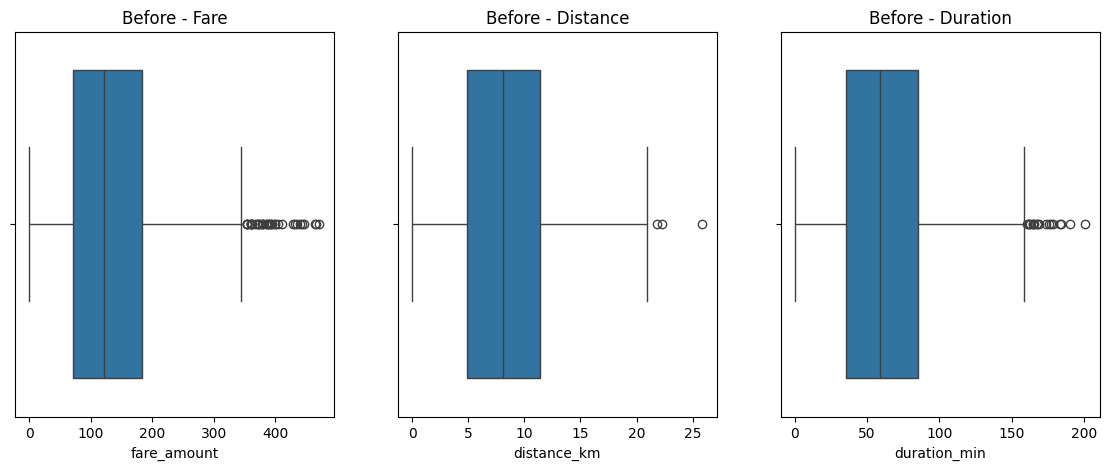

In [128]:

# Before Outlier Handling

plt.figure(figsize=(14,5))

plt.subplot(1,3,1)
sns.boxplot(x=df['fare_amount'])
plt.title('Before - Fare')

plt.subplot(1,3,2)
sns.boxplot(x=df['distance_km'])
plt.title('Before - Distance')

plt.subplot(1,3,3)
sns.boxplot(x=df['duration_min'])
plt.title('Before - Duration')

plt.show()


In [129]:

# Z-score Method

z_fare = np.abs(zscore(df['fare_amount']))
z_distance = np.abs(zscore(df['distance_km']))

df = df[(z_fare < 3) & (z_distance < 3)]

print("Z-score outliers removed")


Z-score outliers removed


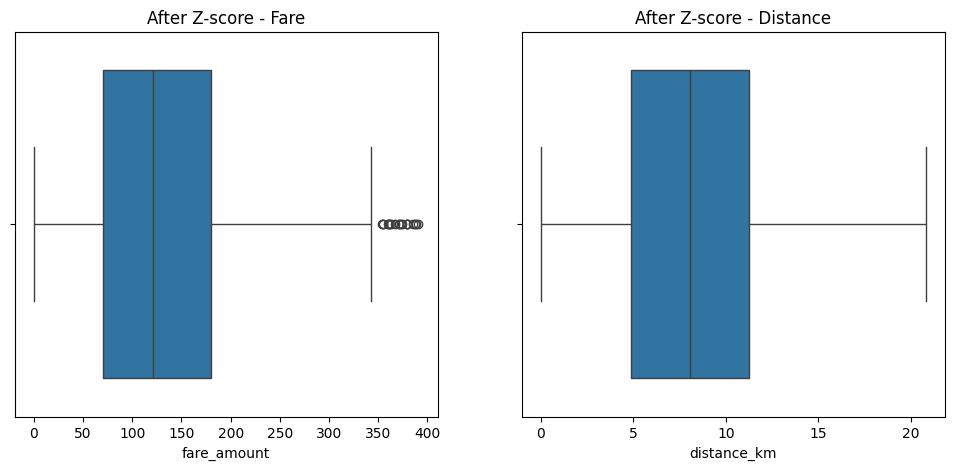

In [130]:

# After Z-score

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['fare_amount'])
plt.title('After Z-score - Fare')

plt.subplot(1,2,2)
sns.boxplot(x=df['distance_km'])
plt.title('After Z-score - Distance')

plt.show()


In [131]:

# IQR Method

Q1 = df['duration_min'].quantile(0.25)
Q3 = df['duration_min'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['duration_min'] >= lower) & (df['duration_min'] <= upper)]

print("IQR outliers removed")


IQR outliers removed


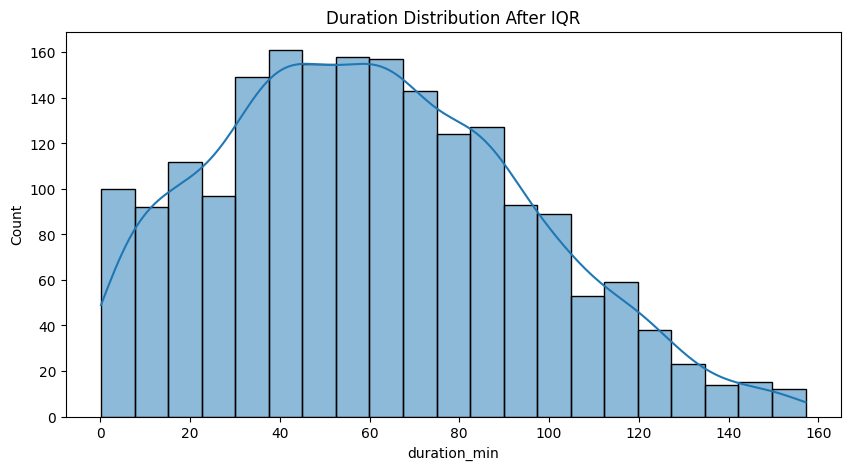

In [132]:

# IQR Visualization

plt.figure(figsize=(10,5))

sns.histplot(df['duration_min'], kde=True)

plt.title('Duration Distribution After IQR')
plt.show()


In [133]:

# Winsorization

df['fare_amount'] = winsorize(df['fare_amount'], limits=[0.05,0.05])

print("Winsorization applied")


Winsorization applied


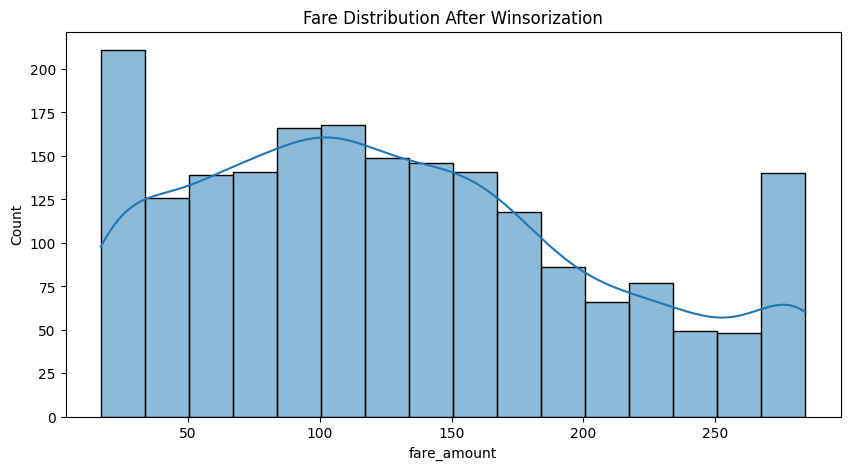

In [134]:

# Winsorization Visualization

plt.figure(figsize=(10,5))

sns.histplot(df['fare_amount'], kde=True)

plt.title('Fare Distribution After Winsorization')

plt.show()


## 4. Feature Construction

In [135]:

# Create Missing Columns using Feature Construction

# Gender Column
np.random.seed(42)

df['gender'] = np.random.choice(
    ['Male', 'Female'],
    size=len(df)
)

# Total Rides
df['total_rides'] = df.groupby('rider_id')['trip_id'].transform('count')

# Cancelled Rides
df['cancelled_rides'] = np.random.randint(
    0,
    5,
    size=len(df)
)

# Traffic Level
df['traffic_level'] = np.where(
    df['ride_date'].dt.hour.between(7,10),
    'High',
    np.where(
        df['ride_date'].dt.hour.between(11,16),
        'Medium',
        'Low'
    )
)

# Signup Date
random_days = np.random.randint(30,1000,size=len(df))

df['signup_date'] = pd.Timestamp.today() - pd.to_timedelta(
    random_days,
    unit='D'
)

print(df[['gender','total_rides','cancelled_rides',
          'traffic_level','signup_date']].head())


   gender  total_rides  cancelled_rides traffic_level  \
0    Male            8                4           Low   
1  Female            9                2           Low   
2    Male            9                1           Low   
3    Male            9                0           Low   
4    Male           10                2           Low   

                 signup_date  
0 2023-10-16 00:03:47.581311  
1 2024-10-12 00:03:47.581311  
2 2025-11-24 00:03:47.581311  
3 2024-03-31 00:03:47.581311  
4 2024-07-05 00:03:47.581311  


## 5. Data Transformation

In [136]:

# Datetime Features

df['hour'] = df['ride_date'].dt.hour
df['day_of_week'] = df['ride_date'].dt.day_name()
df['month'] = df['ride_date'].dt.month_name()

print(df[['hour','day_of_week','month']].head())


   hour day_of_week     month
0     0      Monday  November
1     0      Friday      July
2     0      Sunday   January
3     0   Wednesday  December
4     0   Wednesday     March


In [137]:

# Label Encoding

le = LabelEncoder()

df['gender_encoded'] = le.fit_transform(df['gender'])

print(df[['gender','gender_encoded']].head())


   gender  gender_encoded
0    Male               1
1  Female               0
2    Male               1
3    Male               1
4    Male               1


In [138]:

# One Hot Encoding

one_hot_cols = ['payment_mode', 'zone_name']

existing_cols = [col for col in one_hot_cols if col in df.columns]

df = pd.get_dummies(
    df,
    columns=existing_cols,
    drop_first=True
)

print("One Hot Encoding Applied")


One Hot Encoding Applied


In [139]:

# Ordinal Encoding

ordinal_encoder = OrdinalEncoder(
    categories=[['Low','Medium','High']]
)

df['traffic_level_encoded'] = ordinal_encoder.fit_transform(
    df[['traffic_level']]
)

print(df[['traffic_level','traffic_level_encoded']].head())


  traffic_level  traffic_level_encoded
0           Low                    0.0
1           Low                    0.0
2           Low                    0.0
3           Low                    0.0
4           Low                    0.0


In [140]:

# Binning

df['ride_frequency'] = pd.cut(
    df['total_rides'],
    bins=[0,20,50,np.inf],
    labels=['Low','Medium','High']
)

print(df[['total_rides','ride_frequency']].head())


   total_rides ride_frequency
0            8            Low
1            9            Low
2            9            Low
3            9            Low
4           10            Low


In [141]:

# Transformations

df['log_fare'] = np.log1p(df['fare_amount'])

df['log_distance'] = np.log1p(df['distance_km'])

df['sqrt_duration'] = np.sqrt(df['duration_min'])

print(df[['log_fare','log_distance','sqrt_duration']].head())


   log_fare  log_distance  sqrt_duration
0  4.662306      2.551786       8.636550
1  3.725211      1.581038       5.965735
2  3.858411      1.740466       5.570458
3  5.555437      2.489894       7.712328
4  4.300545      2.113843       8.221314


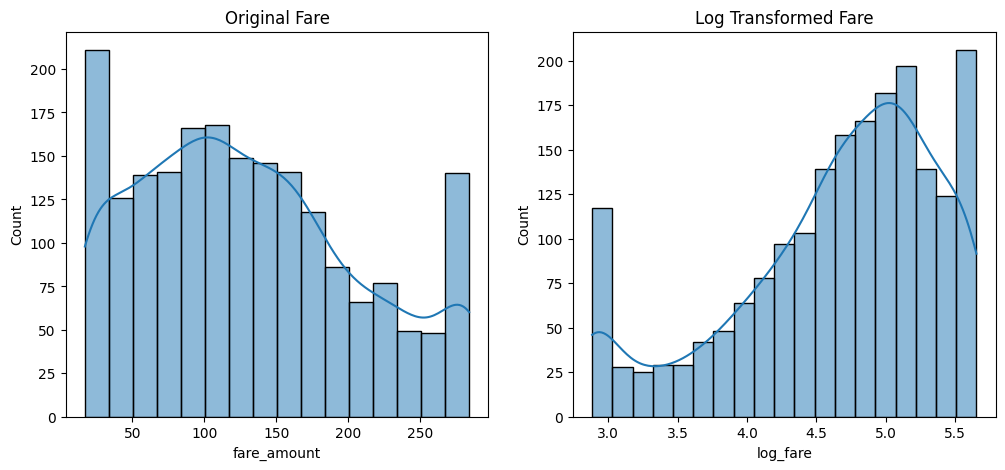

In [142]:

# Transformation Visualization

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['fare_amount'], kde=True)
plt.title('Original Fare')

plt.subplot(1,2,2)
sns.histplot(df['log_fare'], kde=True)
plt.title('Log Transformed Fare')

plt.show()


## 6. Feature Scaling

In [143]:

# Before Scaling

scale_cols = ['fare_amount','distance_km','duration_min']

print(df[scale_cols].describe())


       fare_amount  distance_km  duration_min
count  1971.000000  1971.000000   1971.000000
mean    129.983110     8.091669     60.442319
std      76.130406     4.285214     34.096240
min      16.870000     0.020000      0.190000
25%      69.790000     4.840000     35.175000
50%     120.340000     8.000000     58.420000
75%     179.825000    11.200000     84.110000
max     284.260000    20.780000    157.130000


In [144]:

# Standard Scaling

standard_scaler = StandardScaler()

df_standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(df[scale_cols]),
    columns=[col + '_standard_scaled' for col in scale_cols]
)

print(df_standard_scaled.head())


   fare_amount_standard_scaled  distance_km_standard_scaled  \
0                    -0.329822                     0.872600   
1                    -1.175954                    -0.987755   
2                    -1.098304                    -0.791683   
3                     1.677244                     0.692867   
4                    -0.752099                    -0.189460   

   duration_min_standard_scaled  
0                      0.415039  
1                     -0.729072  
2                     -0.862845  
3                     -0.028231  
4                      0.209686  


In [145]:

# MinMax Scaling

minmax_scaler = MinMaxScaler()

df_minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(df[scale_cols]),
    columns=[col + '_minmax_scaled' for col in scale_cols]
)

print(df_minmax_scaled.head())


   fare_amount_minmax_scaled  distance_km_minmax_scaled  \
0                   0.329145                   0.568882   
1                   0.088298                   0.184971   
2                   0.110401                   0.225434   
3                   0.900445                   0.531792   
4                   0.208946                   0.349711   

   duration_min_minmax_scaled  
0                    0.474067  
1                    0.225564  
2                    0.196508  
3                    0.377788  
4                    0.429463  


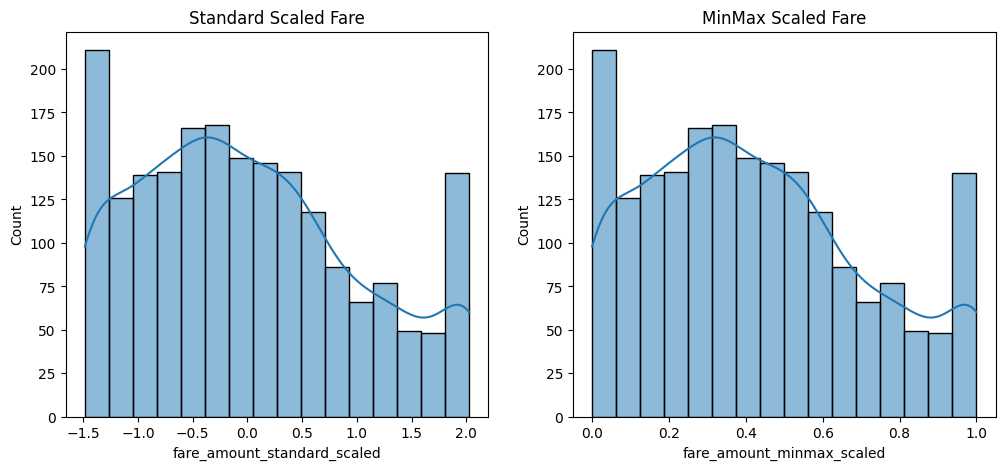

In [146]:

# Scaling Visualization

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_standard_scaled['fare_amount_standard_scaled'], kde=True)
plt.title('Standard Scaled Fare')

plt.subplot(1,2,2)
sns.histplot(df_minmax_scaled['fare_amount_minmax_scaled'], kde=True)
plt.title('MinMax Scaled Fare')

plt.show()


## 7. Advanced Feature Engineering

In [147]:

# Average Ride Distance

avg_distance = df.groupby('rider_id')['distance_km'].mean()

df['avg_ride_distance'] = df['rider_id'].map(avg_distance)

# Average Ride Fare

avg_fare = df.groupby('rider_id')['fare_amount'].mean()

df['avg_ride_fare'] = df['rider_id'].map(avg_fare)

# Peak Hour

df['is_peak_hour'] = np.where(
    (df['hour'].between(7,9)) |
    (df['hour'].between(18,21)),
    1,
    0
)

# Days Since Signup

df['days_since_signup'] = (
    pd.Timestamp.today() - df['signup_date']
).dt.days

# Cancellation Rate

df['ride_cancellation_rate'] = (
    df['cancelled_rides'] / df['total_rides']
)

# Surge Feature

df['surge_feature'] = np.where(
    df['fare_amount']/(df['distance_km']+1) > 20,
    1,
    0
)

print(df.head())


  trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0  T00001    R0037  Zone_10        11.83         74.59       104.88   
1  T00002    R0104   Zone_9         3.86         35.59        40.48   
2  T00003    R0045   Zone_8         4.70         31.03        46.39   
3  T00004    R0089   Zone_2        11.06         59.48       257.64   
4  T00005    R0003   Zone_5         7.28         67.59        72.74   

   ride_date  surge_flag          name   age  ... ride_frequency  log_fare  \
0 2023-11-13         0.0   Aadhya Iyer  32.0  ...            Low  4.662306   
1 2023-07-28         1.0    Diya Gupta  52.0  ...            Low  3.725211   
2 2024-01-14         1.0   Saanvi Iyer  34.0  ...            Low  3.858411   
3 2023-12-13         0.0  Saanvi Reddy  48.0  ...            Low  5.555437   
4 2023-03-15         1.0   Kavya Reddy  34.0  ...            Low  4.300545   

  log_distance  sqrt_duration  avg_ride_distance  avg_ride_fare  is_peak_hour  \
0     2.551786       8.

## 8. Final Visualizations

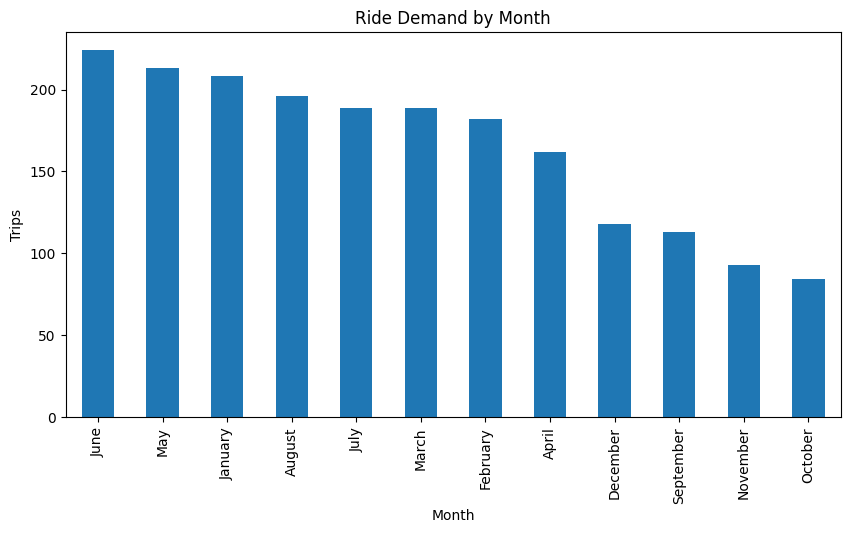

In [148]:

# Ride Demand by Month

monthly_rides = df['month'].value_counts()

plt.figure(figsize=(10,5))

monthly_rides.plot(kind='bar')

plt.title('Ride Demand by Month')
plt.xlabel('Month')
plt.ylabel('Trips')

plt.show()


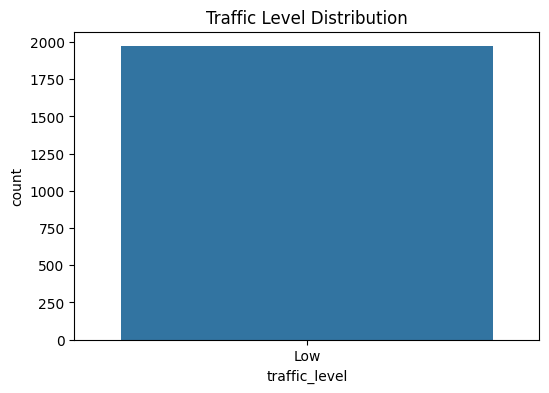

In [149]:

# Traffic Level Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='traffic_level', data=df)

plt.title('Traffic Level Distribution')

plt.show()


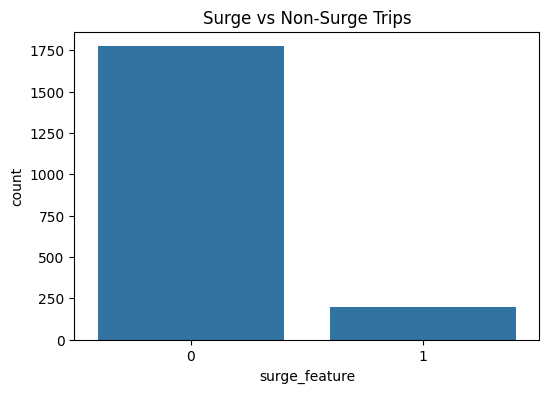

In [150]:

# Surge vs Non-Surge

plt.figure(figsize=(6,4))

sns.countplot(x='surge_feature', data=df)

plt.title('Surge vs Non-Surge Trips')

plt.show()


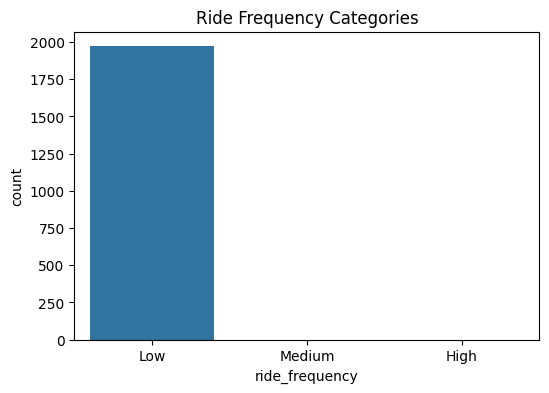

In [151]:

# Ride Frequency Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='ride_frequency', data=df)

plt.title('Ride Frequency Categories')

plt.show()


## 9. Final Dataset

In [152]:

# Summary Table

summary = {
    'Rows Before Cleaning': trips_df.shape[0],
    'Rows After Cleaning': df.shape[0],
    'Missing Values After Cleaning': df.isnull().sum().sum(),
    'Total Columns': df.shape[1]
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=['Metric','Value']
)

print(summary_df)


                          Metric  Value
0           Rows Before Cleaning   2000
1            Rows After Cleaning   1971
2  Missing Values After Cleaning      0
3                  Total Columns     48


In [153]:

# Export Final Dataset

df.to_csv(
    'final_prepared_rides_dataset.csv',
    index=False
)

print("Final dataset exported successfully")


Final dataset exported successfully


In [154]:
# Numerical Columns for Scaling

scale_cols = [
    'fare_amount',
    'distance_km',
    'duration_min',
    'total_rides',
    'cancelled_rides',
    'days_since_signup',
    'avg_ride_distance',
    'avg_ride_fare',
    'ride_cancellation_rate'
]

In [155]:
# =====================================
# Export Fully Scaled Dataset
# =====================================

scaled_df = df.copy()

# Apply Standard Scaling
standard_scaler = StandardScaler()

scaled_df[scale_cols] = standard_scaler.fit_transform(
    scaled_df[scale_cols]
)

# Export CSV
scaled_df.to_csv('scaled_rides_dataset.csv', index=False)

print("Fully Scaled Dataset Exported Successfully")
print(scaled_df.head())

Fully Scaled Dataset Exported Successfully
  trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0  T00001    R0037  Zone_10     0.872600      0.415039    -0.329822   
1  T00002    R0104   Zone_9    -0.987755     -0.729072    -1.175954   
2  T00003    R0045   Zone_8    -0.791683     -0.862845    -1.098304   
3  T00004    R0089   Zone_2     0.692867     -0.028231     1.677244   
4  T00005    R0003   Zone_5    -0.189460      0.209686    -0.752099   

   ride_date  surge_flag          name   age  ... ride_frequency  log_fare  \
0 2023-11-13         0.0   Aadhya Iyer  32.0  ...            Low  4.662306   
1 2023-07-28         1.0    Diya Gupta  52.0  ...            Low  3.725211   
2 2024-01-14         1.0   Saanvi Iyer  34.0  ...            Low  3.858411   
3 2023-12-13         0.0  Saanvi Reddy  48.0  ...            Low  5.555437   
4 2023-03-15         1.0   Kavya Reddy  34.0  ...            Low  4.300545   

  log_distance  sqrt_duration  avg_ride_distance  avg_ride_fa


# ✅ Project Completed Successfully

### Tasks Covered:
- Data Loading
- Cleaning
- Imputation
- Outlier Handling
- Feature Construction
- Encoding
- Scaling
- Visualizations
- Final Dataset Export
